GitHub Repository:

https://github.com/SantiLandinezUni/ML-fundamentals-2026

# Machine Learning Assignment 1

### Step 1: Identifying the Prediction Target

In [1]:
#%pip install numpy
#%pip install pandas
#%pip install -U scikit-learn
#%pip install matplotlib-inline

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("bank-additional.csv", sep=";")
df.shape

(4119, 21)

In [4]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


The target variable is already labeled as "**y**" and it is a binary variable, leading me to think that this problem could be solved through logistic regression. Next I will separate it from the rest of the dataset. This variable is best for this prediction as it directly is the measure of weather the client subscribed or not. In the case of this marketing campaign, this is the main goal as we are trying to get as many customers to subscribe as possible.

In [5]:
X = df.drop("y", axis = 1)
y = df["y"]

From the dataset that 3 other variable could be seen as the target variable superficially. Firstly, '**duration**', which is the time in seconds that the call took. This variables should not be used as it does not really predict if the customer subscribed or not. This should be a predictor as it could even cause leakage as you only get this data after the phone call ended (after y). The second variable that could be considered a target is '**campaign**', which represents the number of contacts performed during this campaign for the client. Although this might seem like the target as it is directly related to the campaign, it does not indicate teh success of the campaign at all but rather if the campaign was operating efficiently. Finally, the last variable that seemed it could be the target to me is '**pdays**' which shows the number of days since last contact. This variable could seem as the target as one could infer that if the number of days is low, then the campaign did succeed. But again it isnt the target as it does not directly tell you if it succeeded or not, and again I think this could cause leakage.

### Step 2: Data Loading and Exploration

In [6]:
import matplotlib.pyplot as plt

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   str    
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   float64
 18 

In [8]:
df.dtypes

age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

We have 19 variables. 10 are numerical and 9 are categorical variables. The code above shows their specific type. From hindsight, the code says that there are no missing values but when looking at the table itself there are some, but they are labeled as unknown. I will now split the numerical and categorical variables

In [9]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


This shows that the scales are extremely different for most variables and again shows that there of no missing values. Below I will do the same but for categorial variables.

In [10]:
df.describe(exclude="number")

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,1012,2509,1264,3315,2175,3349,2652,1378,860,3523,3668


Now I will identify which are categorical and which are numerical which can be done with a simple command.

In [11]:
numerical_cols = X.select_dtypes(include="number").columns
categorical_cols = X.select_dtypes(exclude="number").columns

print("Numerical columns:", list(numerical_cols))
print("Categorical columns:", list(categorical_cols))

Numerical columns: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


Now we look at the target variable and analyze it by itself -->

In [12]:
y.value_counts()

y
no     3668
yes     451
Name: count, dtype: int64

In [13]:
y.value_counts(normalize=True) * 100

y
no     89.05074
yes    10.94926
Name: proportion, dtype: float64

We can see from this code that there are 3668 no's and only 451 yes's which make the data extremely imbalanced being an issue for the model in the future. This be an issue for precision and recall as almost 90% of the data are no's. Next we move onto missing values detection which has already been discussed previously.

In [14]:
df.isna()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4114,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4115,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4116,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4117,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Again we can see that the data shows no missing values, but it does have missingness labeled as Unknown as mentioned before. To identify and analyze these, I have to use different code to find and count these values.

In [15]:
unknown_counts = (df[categorical_cols] == "unknown").sum()
unknown_counts

job             39
marital         11
education      167
default        803
housing        105
loan           105
contact          0
month            0
day_of_week      0
poutcome         0
dtype: int64

Here we can clearly see that there are missing values now. Luckily, in 4 variables there isnt a single missing value, and overall in proportion to teh total data amount, the only variable that has a significant amount of missing values according to the rule of thumb is '**default**' with 803. The others have less than 10% of missingness which is very good.

After going back and analyzing the variable again, I have found that it specifically represents whether the client currently has credit in default (i.e., failed to repay a loan).The large number of "unknown" entries suggests that the bank did not have reliable information about clients’ default status. This represents implicit missingness rather than random noise. For this reason, I believe that these unknowns should be kept as unknowns rather that replacing them as missing values (which they are not exactly) due to them carrying information. If I were to impute them, they may skew the data and mess up the model as they may have predictive power themselves.

Now we move onto visualizing the variables:

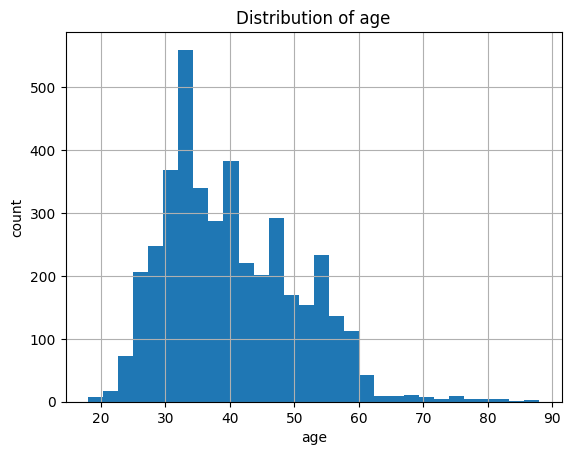

In [16]:
df["age"].hist(bins=30)
plt.title("Distribution of age")
plt.xlabel("age")
plt.ylabel("count")
plt.show()

The distribution of '**age**' seems close to normal, although it has very high spikes. The values seems balanced which is good moving forward.

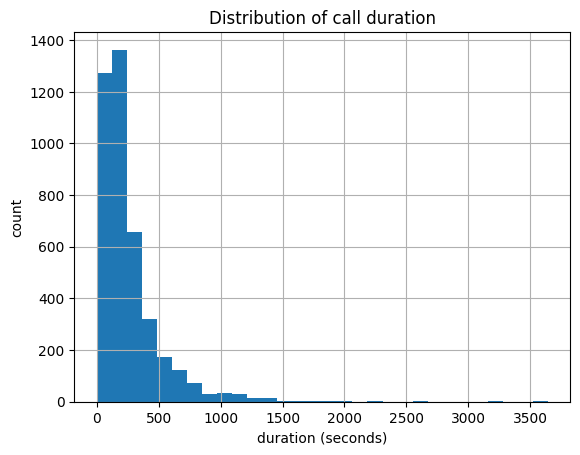

In [17]:
df["duration"].hist(bins=30)
plt.title("Distribution of call duration")
plt.xlabel("duration (seconds)")
plt.ylabel("count")
plt.show()

'**duration**' requires special consideration because it is only known after the call has occurred, meaning that it could cause leakage. Additionally it seems that the data is very zero inflated which might be an issue. In any case, this variables should need special consideration.

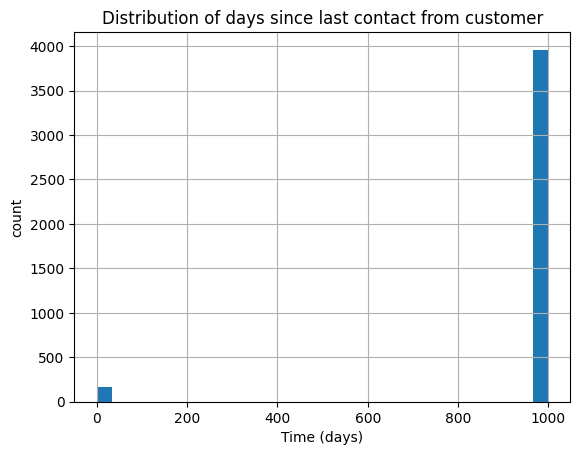

In [18]:
df["pdays"].hist(bins=30)
plt.title("Distribution of days since last contact from customer")
plt.xlabel("Time (days)")
plt.ylabel("count")
plt.show()

After going back to the data and analyzing it, I found that the variable '**pdays**' contains a sentinel value of 999, which indicates that the client was not previously contacted. This creates a large spike in the distribution. Therefore, 999 does not represent an actual number of days and should be graphed to analyze distribution without this value.

This suggests that '**pdays**' may need special preprocessing, as these values could be treated as missing or set as a new variables that shows if the customer has been called before (binary).

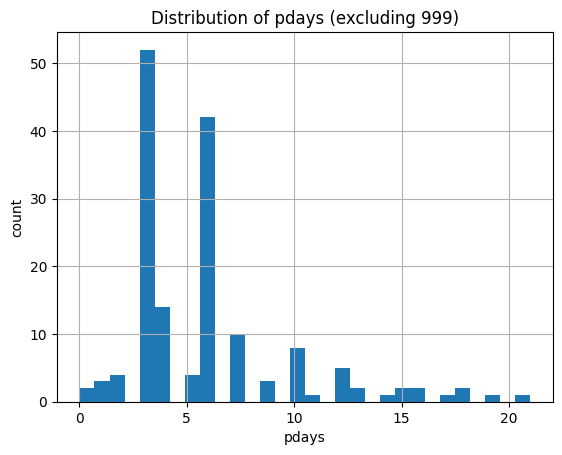

In [19]:
plt.figure()
df[df["pdays"] != 999]["pdays"].hist(bins=30)
plt.title("Distribution of pdays (excluding 999)")
plt.xlabel("pdays")
plt.ylabel("count")
plt.show()

This variable is very skewed and have a high range of values with most being small and close to 0.

Now lets move onto the categorical variables.

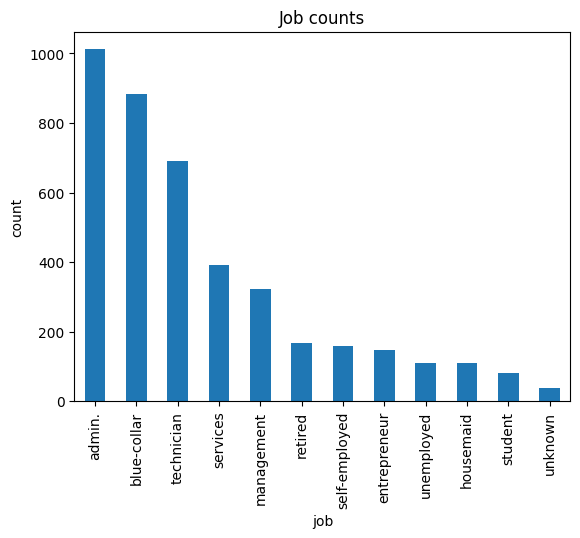

In [20]:
df["job"].value_counts().plot(kind="bar")
plt.title("Job counts")
plt.xlabel("job")
plt.ylabel("count")
plt.show()


The variable '**job**' seems to be ok so far, and I believe could have a lot of predictive power, due to its many categories. Looking at the graph we can see that most values come from 'admin','blue-collar', and 'technician'.

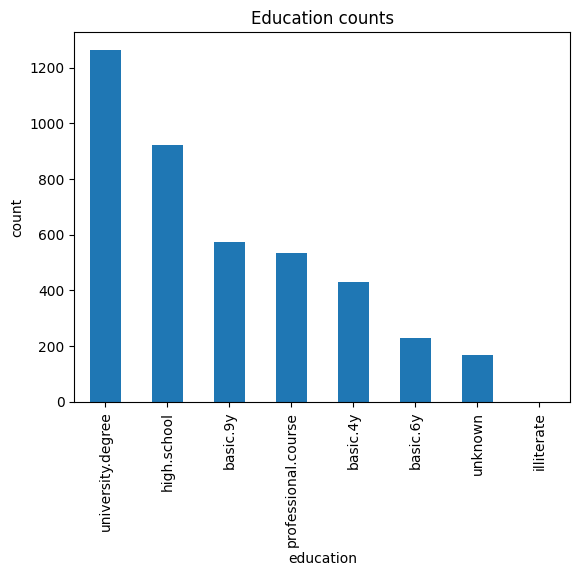

In [21]:
df["education"].value_counts().plot(kind="bar")
plt.title("Education counts")
plt.xlabel("education")
plt.ylabel("count")
plt.show()

Again, the graph for '**education**' seems to be ok. The issue I find from it is that there seems to be close to no values for 'illiterate', but it seems fitting to the data as most people who are called are not illiterate.

After analyzing this variable more closely I find that it may require special consideration because it is an ordinal categorical variable. The levels have a natural ordering (illiterate < basic.4y < basic.6y < high.school < university.degree).
Treating it as nominal ignores this detail. Therefore, the encoding strategy must be carefully justified.
Additionally, the presence of the category "unknown" introduces implicit missingness that
requires a modeling decision.

### **Step 3: Data Splitting**

In [22]:
from sklearn.model_selection import train_test_split

First we will split only into train and test and the sklearn library allows me to do so with one simple line.

In [23]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=2026)

Now we basically replicate this code, but to split the test into validation and test:

In [24]:
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=2026)

**Why this split of 70, 15, 15?**

I decided to split the dataset into 70% training, 15% validation, and 15% test sets.
The training set is kept large to allow stable parameter estimation and that is why I kept 70% instead of 60%. Even like this, the training and validation sets are suficiently large enough to provide reliable performance in the model. I want the data to be very well trained with a lot of data.

**Why did I choose to stratify the target(y)?**

I made the decision to stratify the data with the purpose of preserving the original class distribution of the target variable across all splits. Since the dataset is extremely imbalanced, non-stratified splitting could result in validation or test sets with disproportionate class representation, leading to what could be unreliable results.

**Why splitting must happen before preprocessing?**

The dataset must be split before performing any transformation that learns parameters from the data such as scaling or imputing, which are the remaining steps in this assignment. It is crucial to do the splitting at this step as if transformations are fitted before splitting, information from validation or test sets may leak into the training process, leading to overly optimistic performance estimates.

**What types of data leakage could arise specifically?**

If the dataset were split only after preprocessing, several types of data leakage could occur. First, there could be **information leakage through preprocessing**, where statistics such as means or standard deviations are computed on the full dataset before splitting, allowing validation and test data to influence how the training data is transformed. During data acquisition and feature engineering, there is also a risk of the unintentional introduction of information about the target. This can lead to **target leakage**, where the target is directly or indirectly encoded in another feature, or through **proxy features**, where another variable is strongly correlated with the target in a biased way. There is also the risk of **temporal leakage** if features include information collected after the prediction time, meaning the model would be learning from the future. Additionally, improper data partitioning can cause **group leakage**, where related samples appear in both training and validation/test sets, leading  to the violation of statistical independence.

### **Step 4: Managing Missing Values**

In [25]:
#Recheck explicit missing values on each split of data
nan_train = X_train.isna().sum().sort_values(ascending=False)
nan_val   = X_val.isna().sum().sort_values(ascending=False)
nan_test  = X_test.isna().sum().sort_values(ascending=False)

print("NaN in train set:")
print(nan_train[nan_train > 0])

print("\nNaN in val set:")
print(nan_val[nan_val > 0])

print("\nNaN in test set:")
print(nan_test[nan_test > 0])

NaN in train set:
Series([], dtype: int64)

NaN in val set:
Series([], dtype: int64)

NaN in test set:
Series([], dtype: int64)


Again we see that there are no explicit missing values in any of the data splits. We will now check for unknowns within each split. This has already been done, but not for each split of data now, so this will make it more clear and visual.

In [26]:
unknown_train = (X_train[categorical_cols] == "unknown").sum().sort_values(ascending=False)
unknown_val   = (X_val[categorical_cols] == "unknown").sum().sort_values(ascending=False)
unknown_test  = (X_test[categorical_cols] == "unknown").sum().sort_values(ascending=False)

print("Unknown counts (train):")
print(unknown_train[unknown_train > 0])

print("\nUnknown counts (val):")
print(unknown_val[unknown_val > 0])

print("\nUnknown counts (test):")
print(unknown_test[unknown_test > 0])

Unknown counts (train):
default      558
education    111
housing       71
loan          71
job           26
marital        6
dtype: int64

Unknown counts (val):
default      122
education     19
housing       19
loan          19
job            8
marital        4
dtype: int64

Unknown counts (test):
default      123
education     37
housing       15
loan          15
job            5
marital        1
dtype: int64


Now I will check for the sentinel value that I know exists in '**pdays**' from my previous research:

In [27]:
sentinel_pdays_train = (X_train["pdays"] == 999).sum()
sentinel_pdays_val   = (X_val["pdays"] == 999).sum()
sentinel_pdays_test  = (X_test["pdays"] == 999).sum()

print("train:", sentinel_pdays_train)
print("val:", sentinel_pdays_val)
print("test:", sentinel_pdays_test)

train: 2778
val: 590
test: 591


Verify these as percentages now -->

In [28]:
print("Sentinel values in train:", (X_train["pdays"] == 999).mean() * 100)

Sentinel values in train: 96.3579604578564


After going back and checking the values for all numerical variables I understand that '**pdays**' is the only feature containing a sentinel value (999), which represents that the client was not previously contacted. No other numerical feature contains artificial codes representing non-measurement states. Other numeric variables represent genuine counts.

Now I want to quantify the extent of missingness (specifically unknown values as they are the only that exist) together so I can come back to the following cell more easily. I now am starting to work only with the training set as this is the only one in which imputation should be done due to leakage.


In [29]:
unknown_count = (X_train[categorical_cols] == "unknown").sum()
unknown_count[unknown_count > 0]

job           26
marital        6
education    111
default      558
housing       71
loan          71
dtype: int64

This shows the exact number of missing values in each variable, those that do not show up, have no missing values at all. We can see that similar to what we saw before the split, default is the variable with the highest number of missing values.

Handling the sentinel value (999) in '**pdays**':

Treating 999 as a genuine numeric value would distort the feature as had been seen in the previous step and mislead the model into interpreting it as an extreme magnitude. Therefore, I would suggest that the sentinel value should ne handled explicitly by transforming '**pdays**' into two components: (1) a new binary variable representing whether the client was previously contacted, and (2) a cleaned numerical variable where 999 is replaced with a neutral value such as 0 in order to preserve a cleaner distribution of the data. This preserves the semantic meaning of the original feature while preventing inappropriate scaling and coefficient distortion in the Logistic Regression model.

In [30]:
for df_split in [X_train, X_val, X_test]:
    # 1) indicator: whether the client was previously contacted
    df_split["previously_contacted"] = (df_split["pdays"] != 999).astype(int)

    # 2) cleaned numeric pdays: replace sentinel 999 with neutral value 0
    df_split["pdays"] = df_split["pdays"].replace(999, 0)

Handling missingness for each variable 1 by 1:

The variable **job** contains a small number of "unknown" entries which is also a very small proportion of the data itself. Since missingness is limited and may reflect an absence information rather than random noise, the "unknown" category should be preserved as its own category during later steps such as encoding. This allows the model to learn whether the absence of job information carries predictive value without introducing imputation bias.

The variable **marital** contains very few "unknown" values, only 6 in total. Given the insignificant proportion, "unknown" should be retained as a separate category rather than imputed. Removing or imputing these entries would provide little to no benefit and may unnecessarily distort the data distribution.

The variable **education** contains a higher but still low number of "unknown" values. Since education level is an ordinal categorical variable and missingness may reflect unrecorded information rather than random absence similarly to the other variables, the "unknown" category should be retained. This approach avoids imposing artificial ordering assumptions through imputation.

The variable **default** is only one that contains a larger proportion of "unknown" values, suggesting that credit default status was frequently unrecorded. I belive this can be infered due to the nature of the variable. Rather than imputing these values, "unknown" will be preserved as a distinct category. This reflects the real-world availability of information and prevents the introduction of artificial assumptions. However, the high proportion of missingness suggests that this variable may have limited predictive power and should be re-evaluated during feature selection as it may not be completely necessary and even cause overfitting.

The variable **housing** includes also contains a limited number of "unknown" entries. These again should be preserved as a separate category, as they represent real uncertainty in the data rather than measurement error.

Similar to **housing**, the variable loan contains a small number of "unknown" values which could gave predictive power themselves. Overall, due to the similar argument of a small proportion of missing values and what their absence may mean, I suggest that all "unknown" values are kept as their own separate category without any imputation which could cause more harm than good in the data.

### Step 5: Encoding Categorical Variables


I will again visualize all the categorical variable as they all will be encoded, but luckily I already separated them before.

In [31]:
print(categorical_cols)

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='str')


From these 10 variables I identified that only 1 of them is ordinal due to its natural order. This is education.

In [32]:
X_train['education'].unique()

<StringArray>
[  'university.degree', 'professional.course',            'basic.4y',
         'high.school',            'basic.9y',             'unknown',
            'basic.6y']
Length: 7, dtype: str

From the code above, I see that there are 6 possible values without counting "unknown" that the **education** variable can take on. It is clear that there is an order as having a higher education is better and in these values the order I identify is clearly: basic.4y < basic.6y < basic.9y < high.school < professional.course < university.degree. Therefore there is an order to the classification, while there isn't any order for any of the other variables. For example, there is no greater **month** or a greater **marital** status.

Following this same idea, I believe that the best encoding for nominal variables is One-Hot encoding as it has no inherent ordering, avoids imposing a numerical ranking, and works very well for a logistic regression which I know is the final goal in mind.

In [33]:
from sklearn.preprocessing import OneHotEncoder

nominal_cols = categorical_cols.drop("education")

ohe = OneHotEncoder(handle_unknown="ignore", drop=None, sparse_output=False)

ohe.fit(X_train[nominal_cols])

X_train_ohe = ohe.transform(X_train[nominal_cols])
X_val_ohe   = ohe.transform(X_val[nominal_cols])
X_test_ohe  = ohe.transform(X_test[nominal_cols])

It is important to note that we only fit the encoder onto the train data, not the validation and test. This is because if I were to fit it (after having gotten an error moving forward and having to come back and find it), information leakage through preprocessing would happen due to the validation and test sets being able to see the categories we classified. Therefore, it is crucial that the both the one-hot encoder and the ordinal encoder be fit only on the train data, but we must transform the validation and test sets with the encoders.

Now for the **education** variable I have decided to use an ordinal encoder which exists in the sklearn library. I chose this encoding for this variable as I do consider that is does have meaningful order in its categories as mentioned in the past.

In [34]:
education_order = [
    "illiterate",
    "basic.4y",
    "basic.6y",
    "basic.9y",
    "high.school",
    "professional.course",
    "university.degree",
    "unknown"
]

In [35]:
from sklearn.preprocessing import OrdinalEncoder

ord_enc = OrdinalEncoder(categories=[education_order])
ord_enc.fit(X_train[["education"]])

X_train["education"] = ord_enc.transform(X_train[["education"]])
X_val["education"]   = ord_enc.transform(X_val[["education"]])
X_test["education"]  = ord_enc.transform(X_test[["education"]])

It is important to note that encoding increases the dimensionality of the dataset by expanding categorical variables into multiple binary features depending on the amount of categories each variable has. This affects both model complexity and regularization behavior due to the large change in size of the new dataset. In Logistic Regression, one-hot encoding allows the model to assign separate coefficients to each category, while ordinal encoding imposes a monotonic relationship between levels, thereby influencing the types of linear decision boundaries that can be represented. Luckily in this dataset as mentioned, we are only doing ordinal encoding for one variable and One-hot encoding for the rest.

At the end of this step I want to immediately remove the **duration** variable from the data as it will cause leakage and I want to remove than before I even start feature scaling. Additionally, I also have to recompute the numeric columns I have as I encoded **education** with ordinal encoding and have now made it into a numeric variable.

In [36]:
from sklearn.feature_selection import VarianceThreshold
if "duration" in X_train.columns:
    X_train = X_train.drop(columns=["duration"])
    X_val   = X_val.drop(columns=["duration"])
    X_test  = X_test.drop(columns=["duration"])

numeric_cols_new = X_train.select_dtypes(include="number").columns

Now check if it worked

In [37]:
numeric_cols_new

Index(['age', 'education', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed',
       'previously_contacted'],
      dtype='str')

In [38]:
import numpy as np
X_train_num = X_train[numeric_cols_new]
X_val_num   = X_val[numeric_cols_new]
X_test_num  = X_test[numeric_cols_new]

ohe_feature_names = ohe.get_feature_names_out(nominal_cols)

# Stack into final arrays
X_train_full = np.hstack([X_train_num, X_train_ohe])
X_val_full   = np.hstack([X_val_num,   X_val_ohe])
X_test_full  = np.hstack([X_test_num,  X_test_ohe])

### Step 6: Feature Scaling

For this step we will have to scale all numeric variables in my dataset in order for the feature selection with low variance to be able to function properly. As I saw in past steps, the variables all have very different scales which could throw off the variance, making this step crucial before feature selection. All of my variables will be printed down below again:

In [39]:
numeric_cols_new

Index(['age', 'education', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed',
       'previously_contacted'],
      dtype='str')

Next I will use standardization for with the StandardScalar command in this data.

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num_scaled = scaler.fit_transform(X_train_num) #only on training data

# Transform validation and test
X_val_num_scaled = scaler.transform(X_val_num)
X_test_num_scaled = scaler.transform(X_test_num)

After fitting and transforming the sets with the scalar, we want to remake the sets with the scales adjusted.

In [41]:
X_train_full = np.hstack([X_train_num_scaled, X_train_ohe])
X_val_full   = np.hstack([X_val_num_scaled,   X_val_ohe])
X_test_full  = np.hstack([X_test_num_scaled,  X_test_ohe])

StandardScaler (standardization) centers each variable to zero mean and unit variance. After research I found that Standardization is particularly important for Logistic Regression because the model is trained using gradient-based optimization. When features are measured on different scales, variables with large magnitudes can dominate the gradient updates, leading to slower convergence and numerical instability. By scaling all numerical features to a comparable range, optimization becomes more stable and efficient. Additionally, Logistic Regression usually uses L2 regularization, which penalizes large coefficients as learned in class due to squaring the error. Without scaling, features with smaller numerical ranges would receive disproportionately large coefficients and thus be penalized more heavily. Standardization ensures that regularization is applied uniformly across features, making coefficient magnitudes more comparable and improving interpretability. The scaler was fitted exclusively on the training set to prevent data leakage, and the learned parameters were then applied to the validation and test sets.

### Step 7: Feature Selection

In [42]:
feature_names = list(numeric_cols_new) + list(ohe.get_feature_names_out(nominal_cols))

In [43]:
print(feature_names)

['age', 'education', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'previously_contacted', 'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_divorced', 'marital_married', 'marital_single', 'marital_unknown', 'default_no', 'default_unknown', 'default_yes', 'housing_no', 'housing_unknown', 'housing_yes', 'loan_no', 'loan_unknown', 'loan_yes', 'contact_cellular', 'contact_telephone', 'month_apr', 'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_fri', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'poutcome_failure', 'poutcome_nonexistent', 'poutcome_success']


In [44]:
variances = X_train_full.var(axis=0)

var_df = pd.DataFrame({
    "feature": feature_names,
    "variance": variances
}).sort_values("variance")

var_df

,feature,variance
29,default_yes,0.000347
26,marital_unknown,0.002077
40,month_dec,0.004832
22,job_unknown,0.008937
43,month_mar,0.011993
46,month_oct,0.014693
47,month_sep,0.015365
19,job_student,0.020711
14,job_housemaid,0.022700
31,housing_unknown,0.024021


Here I can all the variances and can there that there are clearly more dominant variables like nr.employed and that many variables have very low variances which could be removed from the data. It is also clear that most low variance features are those that were One-hot encoded.

For a binary variable, variance is given by Var(X)=p(1−p), which is the bernoulli variance of p, where p is the proportion of observations belonging to that category. For small values of p, variance approximates p. A threshold of 0.005 corresponds approximately from this calculation to categories appearing in fewer than 0.5% of the training observations. Such rare categories contribute little generalizable information, may lead to unstable coefficient estimates in Logistic Regression, and can increase the risk of overfitting. The chosen threshold thus removes extremely rare categories while preserving informative features.

In [45]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.005)

X_train_var = selector.fit_transform(X_train_full)
X_val_var   = selector.transform(X_val_full)
X_test_var  = selector.transform(X_test_full)

selected_mask = selector.get_support()
selected_features = np.array(feature_names)[selected_mask]

print("Removed features:", len(feature_names) - len(selected_features))


Removed features: 3


With this threshold, only 3 features were removed, which indicates that the encoding was effective and didn't create a lot of irrelevant variables. Now I will check for highly correlated features.

In [46]:
num_df = pd.DataFrame(X_train_num_scaled, columns=numeric_cols_new)
corr_matrix = num_df.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

correlation_threshold = 0.85

to_drop_corr = [column for column in upper_triangle.columns
                if any(upper_triangle[column] > correlation_threshold)]

print("Highly correlated features to drop:", to_drop_corr)

Highly correlated features to drop: ['euribor3m', 'nr.employed']


In this part I decided that the threshold should be 0.85 as according to theory, if two variables are share a coefficient of correlation of 0.85 or above it is considered strong correlation meaning that there ir strong redundancy. I find that 0.85 is conservative for pruning as it removed 2 varibales which seems fitting.

In [47]:
corr_features_to_remove = [f for f in selected_features if f in to_drop_corr]

# Remove from feature set
final_features = [f for f in selected_features if f not in corr_features_to_remove]

print("Final feature count:", len(final_features))

Final feature count: 51


As seen, after removing these variables, the final feature count is 51.

After reviewing the variables again to determine whether any should be removed based on conceptual considerations, I conclude that the primary source of potential data leakage has already been addressed through the removal of the variable **duration**. Including it would introduce target leakage and result in an unrealistically optimistic model evaluation. Besides this, the remaining variables are available at prediction time and reflect client, campaign, or macroeconomic information, at least to my understanding. While some macroeconomic variables seem moderately correlated, they do not pose conceptual concerns regarding leakage or temporal availability. Therefore, no additional features are removed on conceptual grounds at this stage, as the current feature set remains consistent with a realistic deployment scenario. Although I still have 51, which at hindsight seems light a lot to me, the dataset does contain a high ratio of observations per variable, meaning that this should not be a big issue initially.

**Why feature selection must use training set only?**

In this step, I made sure to perform feature selection using only the training set in order to preserve the validity of the evaluation process. Even though the methods used  (low variance filtering and correlation analysis) do not directly involve the target variable, they still rely on information derived from the data. If I were to compute these statistics on the entire dataset, I would unintentionally incorporate distributional information from the validation and test sets into the model-building process. This would introduce data leakage by training the model with not only the training data. To avoid this, I first split the data and then performed feature selection exclusively on the training set, applying the resulting feature mask to the validation and test sets without refitting. This ensures that the validation and test results remain a fair estimate of the model’s ability to generalize.

**Consequences of Performing Feature Selection Before Splitting**

If I had performed feature selection before splitting the dataset, the validation and test sets would no longer be truly unseen. The selection step would already have been influenced by their distribution, again meaning the model would be trained from data it should not see. This would likely lead to overly optimistic performance estimates and reduce the reliability of the evaluation. By splitting first and then conducting feature selection, I ensure that the modeling process mirrors a realistic prediction setting and avoids unintended leakage.

### Step 8: Addressing Class Imbalance

In [48]:
class_counts = y_train.value_counts()
class_proportions = y_train.value_counts(normalize=True)

print("Class counts:\n", class_counts)
print("\nClass proportions:\n", class_proportions)

Class counts:
 y
no     2567
yes     316
Name: count, dtype: int64

Class proportions:
 y
no     0.890392
yes    0.109608
Name: proportion, dtype: float64


Here we can clearly see that the training set has a high class imbalance with almost 90% of the values being 'no'. This imbalance is relevant because a model trained without adjustment may become biased toward predicting the majority class.

This imbalance is a big problem in the data as when looking at the large context, the goal of this model would be to estimate which customers will actually subscribe to the service. Therefore, predicting those that don't is not that relevant in the model.

To address class imbalance, I believe that  SMOTE (Synthetic Minority Over-sampling Technique) is the best technique to apply to the training set. SMOTE generates synthetic samples of the minority class (in this case 'yes') by interpolating between existing minority instances in feature space. This approach is preferable to simple random oversampling which is the most common option, because it reduces the risk of overfitting caused by exact duplication of minority samples. Since numerical variables were standardized already, SMOTE operates in a well-conditioned feature space with the same scales in all the variables, producing more meaningful synthetic observations. The resampling step will be applied only on the training data to avoid any leakage.

In [49]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state = 2026)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_var, y_train
)

print("Original training shape:", X_train_var.shape)
print("Resampled training shape:", X_train_resampled.shape)

print("\nResampled class distribution:")
print(pd.Series(y_train_resampled).value_counts(normalize=True))

Original training shape: (2883, 53)
Resampled training shape: (5134, 53)

Resampled class distribution:
y
no     0.5
yes    0.5
Name: proportion, dtype: float64


Here we can see that the SMOTE worked, and we have a new resampled data **X_train_resampled** which is perfectly balanced with 50-50 of the target variable.

**What Would Happen If Resampling Were Applied Before Splitting?**

If resampling were applied before splitting the dataset into training, validation, and test sets, it would introduce data leakage and ruin the validity of the evaluation when trying to generalize. Techniques such as SMOTE generate synthetic minority samples by interpolating between existing observations in feature space. If this process were performed on the full dataset, synthetic samples would be created using information from observations that later belong to the validation or test sets. In consequence, the model would gain access to unseen data, leading to overly optimistic performance estimates on the test data, while not being the case in the real world. To maintain proper order of the pipeline, resampling must be applied only to the training set after splitting. This was constantly mentioned in class as LEAKAGE.

**How class imbalance affects evaluation metrics such as accuracy, precision, and recall**

Class imbalance affects evaluation metrics differently. Accuracy specifically can be misleading because a model predicting only the majority class will achieve a high accuracy which is inflated as it does not predict 'yes' class well. It is important to understand that precision measures the reliability of positive predictions, while recall captures the model’s ability to detect minority instances (as seen in the class slides). In imbalanced classification problems, recall is particularly important when the minority class represents economically valuable outcomes, as is the case in marketing subscription prediction. In this specific case, the imbalanced data would have a very low recall as it had very little data of the 'yes' category to train on.

## Step 9: Training a Logistic Regression Model

In [50]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=5000, solver="liblinear", C=0.1, random_state=2026)
log_reg.fit(X_train_resampled, y_train_resampled)
y_val_pred = log_reg.predict(X_val_var)

I had to add a C value of 0.01, because the model wasn't converging correctly.

In [51]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred, pos_label="yes"))
print("Recall:", recall_score(y_val, y_val_pred, pos_label="yes"))
print("F1 Score:", f1_score(y_val, y_val_pred, pos_label="yes"))

Accuracy: 0.8025889967637541
Precision: 0.31788079470198677
Recall: 0.7164179104477612
F1 Score: 0.44036697247706424


At hind-sight the values do seem realistic even if they are not the best model. Now I will compute the Zero-Rule in order to compare the values and see if it it better overall, even though the accuracy is lower as with the Zero-rule due to the imbalance, the accruacy should be almost 0.9.

In [52]:
majority_class = y_train.value_counts().idxmax()
y_val_zero = [majority_class] * len(y_val)

zero_acc = accuracy_score(y_val, y_val_zero)
print("Zero Rule Accuracy:", zero_acc)

zero_recall = recall_score(y_val, y_val_zero, pos_label="yes")

print("Zero Rule Recall:", zero_recall)


Zero Rule Accuracy: 0.8915857605177994
Zero Rule Recall: 0.0


The Logistic Regression model achieves an accuracy of approximately 0.80 on the validation set, which is slightly lower than the Zero Rule baseline that always predicts the majority class. However, the model achieves a recall of approximately 0.72 for the minority class, meaning it correctly identifies around 72% of actual subscription cases. In contrast, the Zero Rule classifier achieves zero recall for the positive class. Although precision is moderate (0.32), this trade-off is expected in imbalanced classification problems. Overall, the results suggest that the preprocessing pipeline are working correctly together and producing a model that meaningfully captures the minority-class, rather than being completely overtaken by the majority class.